# Week 8 Activity: Onset Detection and Autocorrelation

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

## Onset Detection

Read in the following files below, and normalize.

a) 80sPopDrums.wav  
b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
c) prelude_cmaj_10s.wav  

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from IPython.display import Audio
import librosa, librosa.display
plt.rcParams['figure.figsize'] = (14, 5)
from scipy.io.wavfile import read

# a) 80sPopDrums.wav
(fs_a, x_a) = read('../audio/80sPopDrums.wav')
xnorm_a = x_a/np.abs(x_a.max())

# b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
(fs_b, x_b) = read('../audio/TheBlackKeys_track4.wav')
xnorm_b = x_b/np.abs(x_b.max())

# c) prelude_cmaj_10s.wav  
(fs_c, x_c) = read('../audio/prelude_cmaj_10s.wav')
x_c = x_c.mean(axis=1) # convert to mono for librosa to run properly
xnorm_c = x_c/np.abs(x_c.max())

#### For each of the tracks (start with just one):

1) Compute the energy and RMSE for each track using a frame length of your choice  
2) Plot the energy and the RMSE
3) Use one of the energy features to create your novelty function and plot
4) Write a peak picking function to define onsets from your novelty function
4) Based on the plots, estimate what an appropriate 'threshold' would be. Does the threshold change across tracks? If so, what could you do to put them on a similar scale?

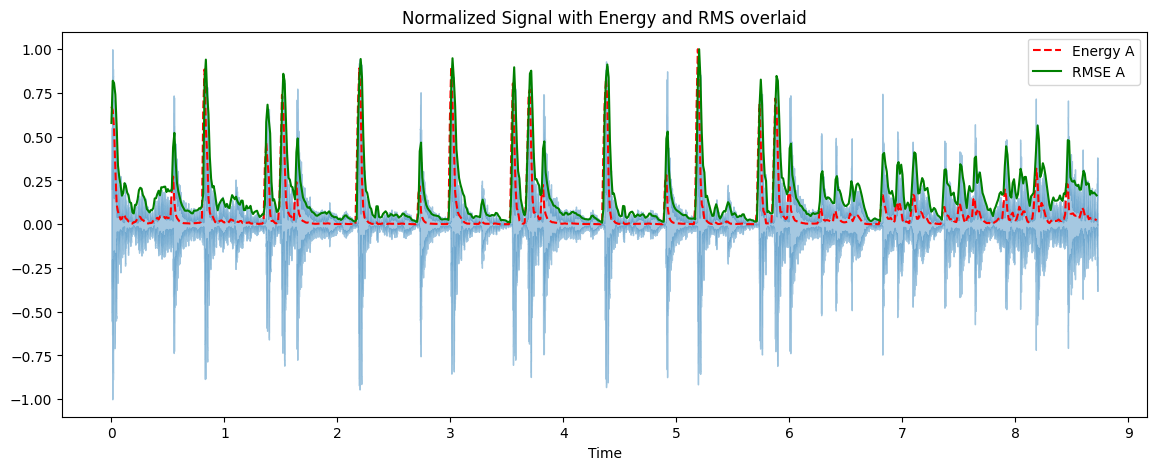

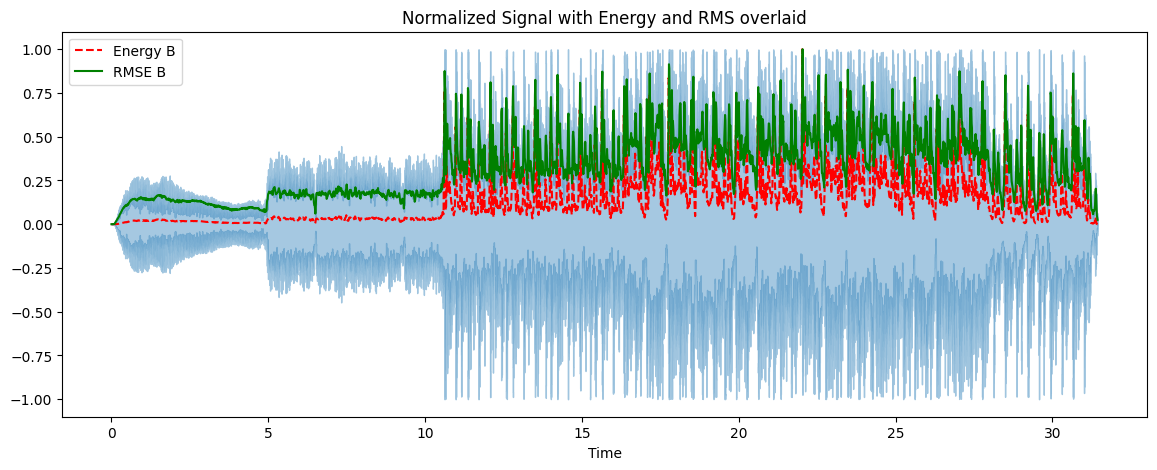

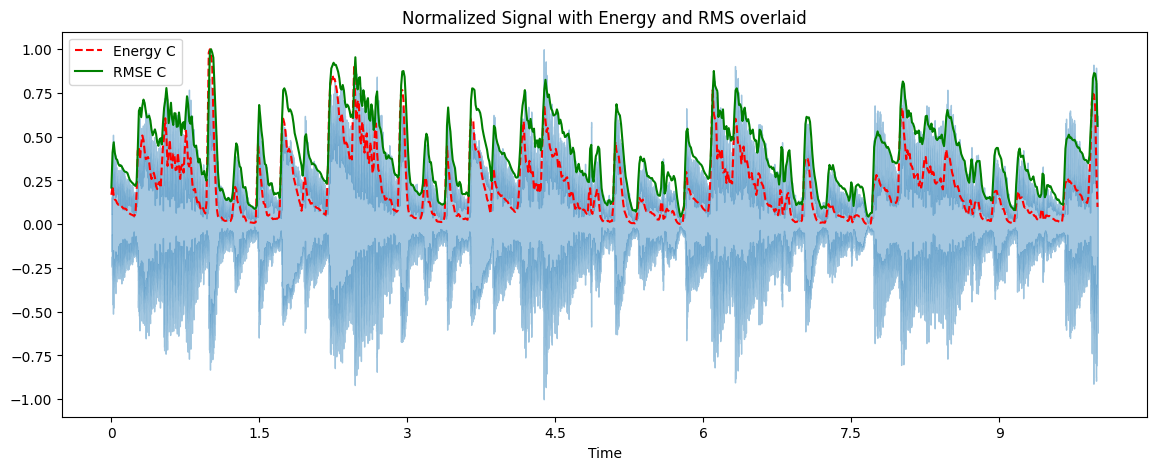

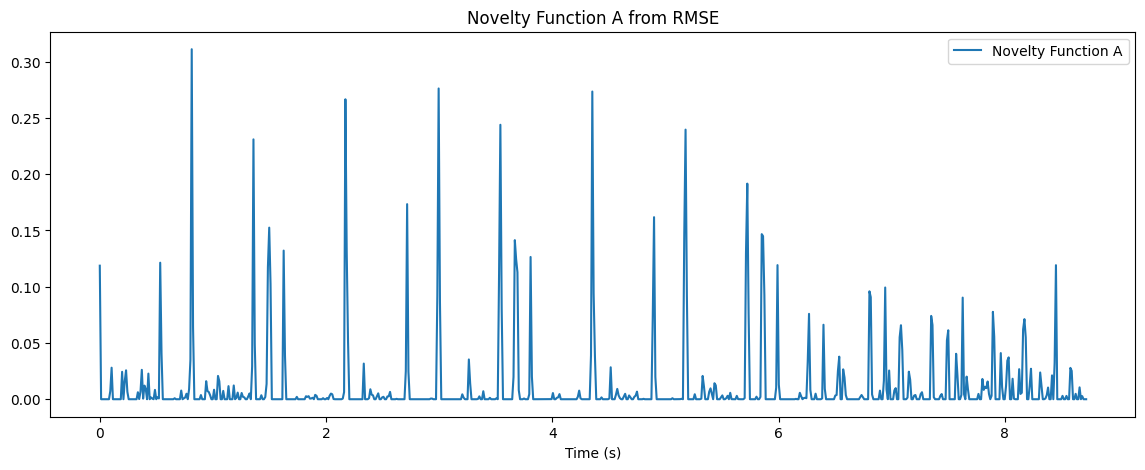

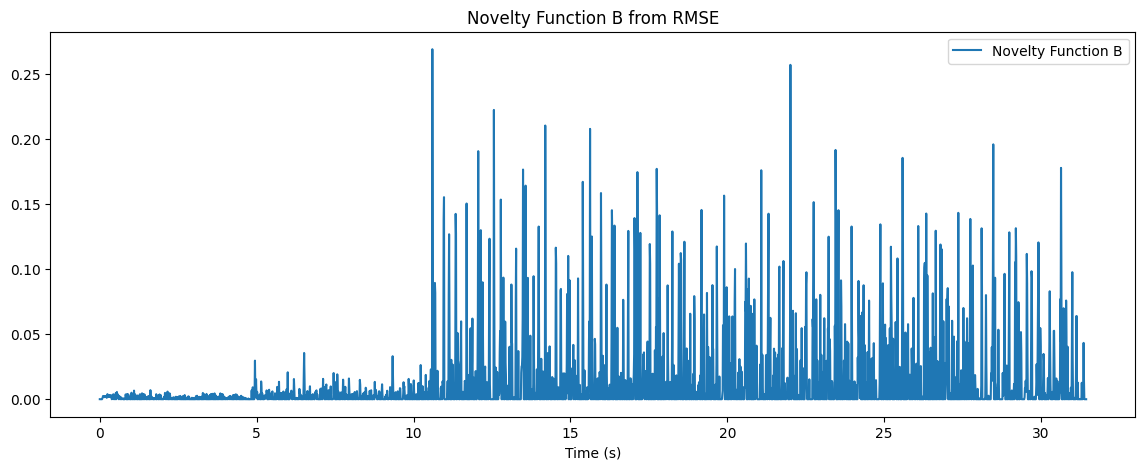

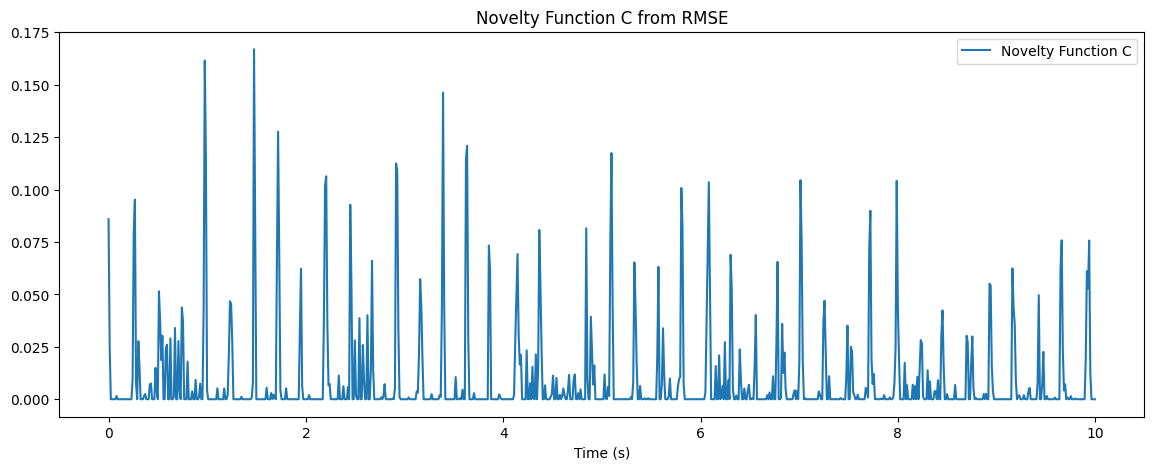

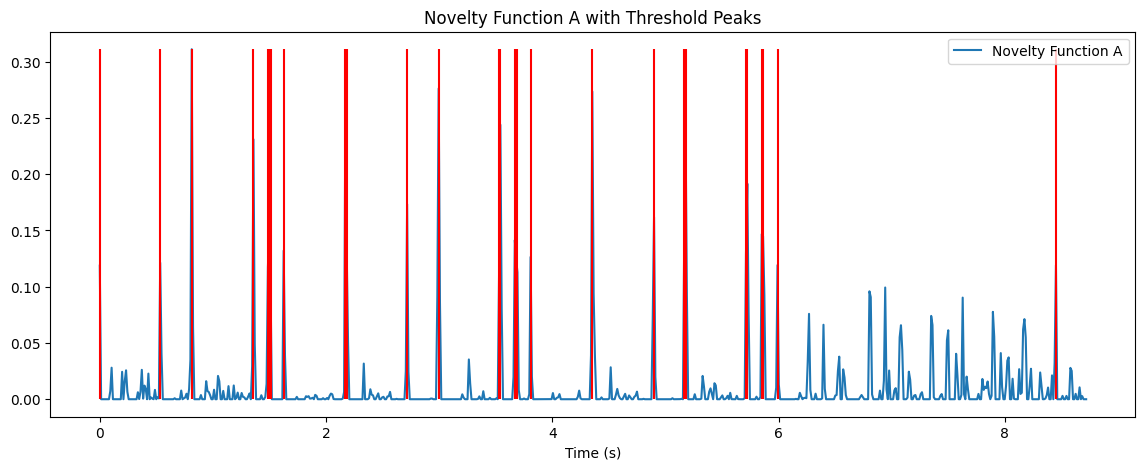

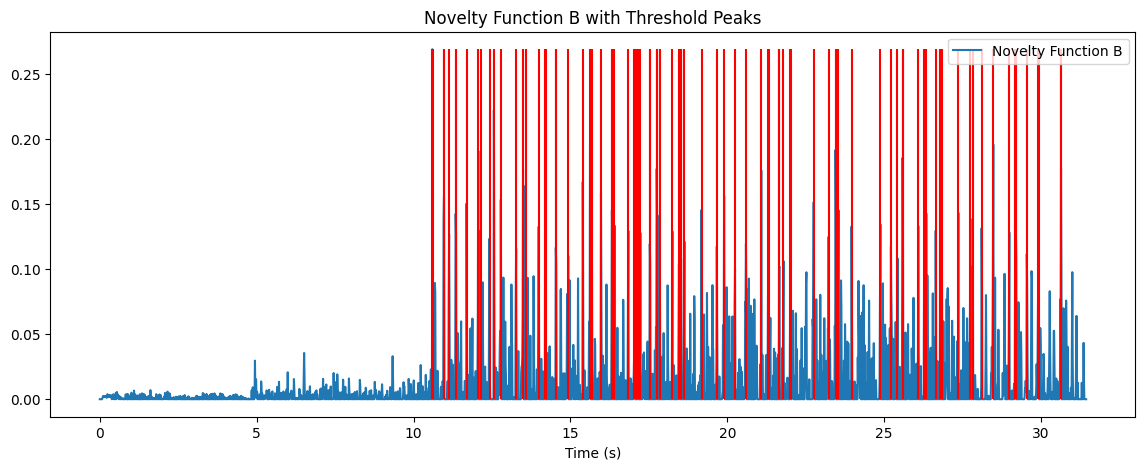

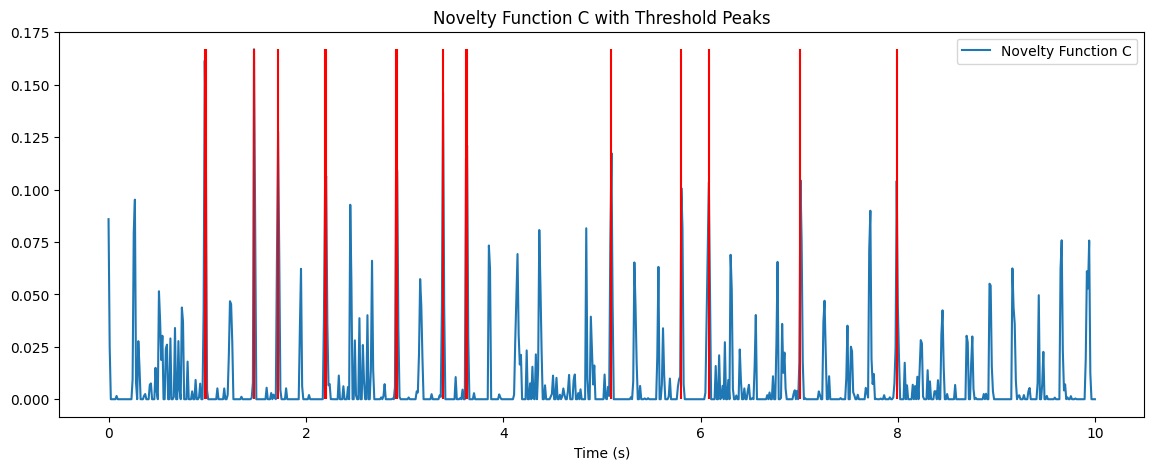

In [ ]:
# 1) Compute energy and RMSE for each track using frame length of your choice
hop_length = 512 # 50% overlap
frame_length = 1024

## 1a)
energy_a = np.array([ # convert output from list comprehension into array
    # 1. grab one frame of samples at a time (i through i+frame_length)
    # 2. take the absolute value of the square of all the samples inside the frame, then sum
    # 3. increment by hop_length & repeat
    sum(abs(xnorm_a[i:i+frame_length]**2)) for i in range(0, len(xnorm_a), hop_length)
])
rmse_a = librosa.feature.rms(y = xnorm_a, frame_length=frame_length, hop_length=hop_length, center=True)


## 1b)
energy_b = np.array([sum(abs(xnorm_b[i:i+frame_length]**2)) for i in range(0, len(xnorm_b), hop_length)])
rmse_b = librosa.feature.rms(y = xnorm_b, frame_length=frame_length, hop_length=hop_length, center=True)

## 1c)
energy_c = np.array([sum(abs(xnorm_c[i:i+frame_length]**2)) for i in range(0, len(xnorm_c), hop_length)])
rmse_c = librosa.feature.rms(y = xnorm_c, frame_length=frame_length, hop_length=hop_length, center=True)



# 2) Plot the energy and the RMSE

## 2a)
frames_a = range(len(energy_a))
t_a = librosa.frames_to_time(frames_a, sr=fs_a, hop_length=hop_length) # create time array for frame values (for vizualizing)
plt.figure()
librosa.display.waveshow(xnorm_a, sr=fs_a, alpha=0.4)
plt.plot(t_a, energy_a/energy_a.max(), 'r--', label='Energy A')       # normalized for visualization
plt.plot(t_a, rmse_a[0]/rmse_a[0].max(), color='g', label='RMSE A')   # normalized for visualization
plt.title('Normalized Signal with Energy and RMS overlaid')
plt.legend()

## 2b)
frames_b = range(len(energy_b))
t_b = librosa.frames_to_time(frames_b, sr=fs_b, hop_length=hop_length) # create time array for frame values (for vizualizing)
plt.figure()
librosa.display.waveshow(xnorm_b, sr=fs_b, alpha=0.4)
plt.plot(t_b, energy_b/energy_b.max(), 'r--', label='Energy B')       # normalized for visualization
plt.plot(t_b, rmse_b[0]/rmse_b[0].max(), color='g', label='RMSE B')   # normalized for visualization
plt.title('Normalized Signal with Energy and RMS overlaid')
plt.legend()

## 3b)
frames_c = range(len(energy_c))
t_c = librosa.frames_to_time(frames_c, sr=fs_c, hop_length=hop_length) # create time array for frame values (for vizualizing)
plt.figure()
librosa.display.waveshow(xnorm_c, sr=fs_c, alpha=0.4)
plt.plot(t_c, energy_c/energy_c.max(), 'r--', label='Energy C')       # normalized for visualization
plt.plot(t_c, rmse_c[0]/rmse_c[0].max(), color='g', label='RMSE C')   # normalized for visualization
plt.title('Normalized Signal with Energy and RMS overlaid')
plt.legend()


# 3) Use one of the energy features to create your novelty function and plot

## 3a)
rmse_diff_a = np.diff(rmse_a[0])
novelty_a = np.concatenate((rmse_diff_a, np.array([0])))  # Add a zero at the end to maintain the same length
novelty_a[novelty_a < 0] = 0
plt.figure()
plt.plot(t_a, novelty_a, label='Novelty Function A')
plt.xlabel('Time (s)')
plt.title('Novelty Function A from RMSE')
plt.legend()
plt.show()

## 3b)
rmse_diff_b = np.diff(rmse_b[0])
novelty_b = np.concatenate((rmse_diff_b, np.array([0])))  # Add a zero at the end to maintain the same length
novelty_b[novelty_b < 0] = 0
plt.figure()
plt.plot(t_b, novelty_b, label='Novelty Function B')
plt.xlabel('Time (s)')
plt.title('Novelty Function B from RMSE')
plt.legend()
plt.show()

## 3c)
rmse_diff_c = np.diff(rmse_c[0])
novelty_c = np.concatenate((rmse_diff_c, np.array([0])))  # Add a zero at the end to maintain the same length
novelty_c[novelty_c < 0] = 0
plt.figure()
plt.plot(t_c, novelty_c, label='Novelty Function C')
plt.xlabel('Time (s)')
plt.title('Novelty Function C from RMSE')
plt.legend()
plt.show()


# 4) Write a peak picking function to define onsets from your novelty function

## 4a)
novelty_peaks_a = np.where(novelty_a > 0.1)[0]
peak_times_a = t_a[novelty_peaks_a]
plt.figure()
plt.plot(t_a, novelty_a, label='Novelty Function A')
plt.vlines(peak_times_a, 0, np.max(novelty_a), colors='r')
plt.xlabel('Time (s)')
plt.title('Novelty Function A with Threshold Peaks')
plt.legend()
plt.show()

## 4b)
novelty_peaks_b = np.where(novelty_b > 0.1)[0]
peak_times_b = t_b[novelty_peaks_b]
plt.figure()
plt.plot(t_b, novelty_b, label='Novelty Function B')
plt.vlines(peak_times_b, 0, np.max(novelty_b), colors='r')
plt.xlabel('Time (s)')
plt.title('Novelty Function B with Threshold Peaks')
plt.legend()
plt.show()

## 4c)
novelty_peaks_c = np.where(novelty_c > 0.1)[0]
peak_times_c = t_c[novelty_peaks_c]
plt.figure()
plt.plot(t_c, novelty_c, label='Novelty Function C')
plt.vlines(peak_times_c, 0, np.max(novelty_c), colors='r')
plt.xlabel('Time (s)')
plt.title('Novelty Function C with Threshold Peaks')
plt.legend()
plt.show()

# 5) Based on the plots, estimate what an appropriate 'threshold' would be. 
## 5a) threshold = 0.6
## 5b) threshold = 0.1
## 5c) threshold = 0.07

# Does the threshold change across tracks? If so, what could you do to put them on a similar scale?
# Answer: Yes, the threshold change across tracks. You could normalize each novelty function before thresholding.

## Tempo Estimation

Using your novelty functions and detected onsets above, estimate the global tempo of the files using autocorrelation and IOIs.

1) IOI Based Tempo

- Compute Inter-Onset Intervals (IOIs)
- Convert IOIs to BPM
- Create a beat histogram to help you infer tempos

2) Autocorrelation based Tempo
- Compute the autocorrelation of your novelty function
- Convert lag to BPMs (conside perceptual relevance)
- Crate a beat histogram to help you infer tempos

Text(0.5, 1.0, 'Beat Histogram C (Autocorrelation)')

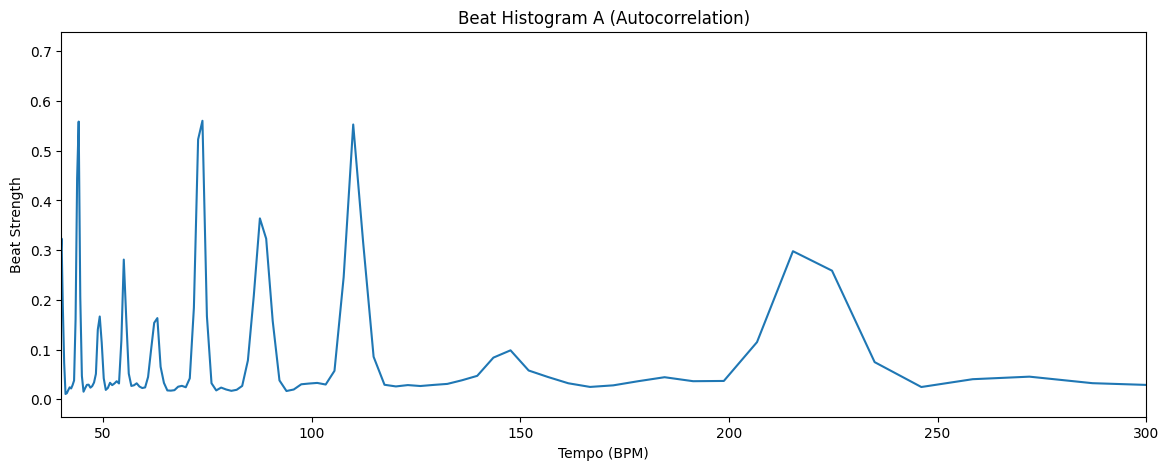

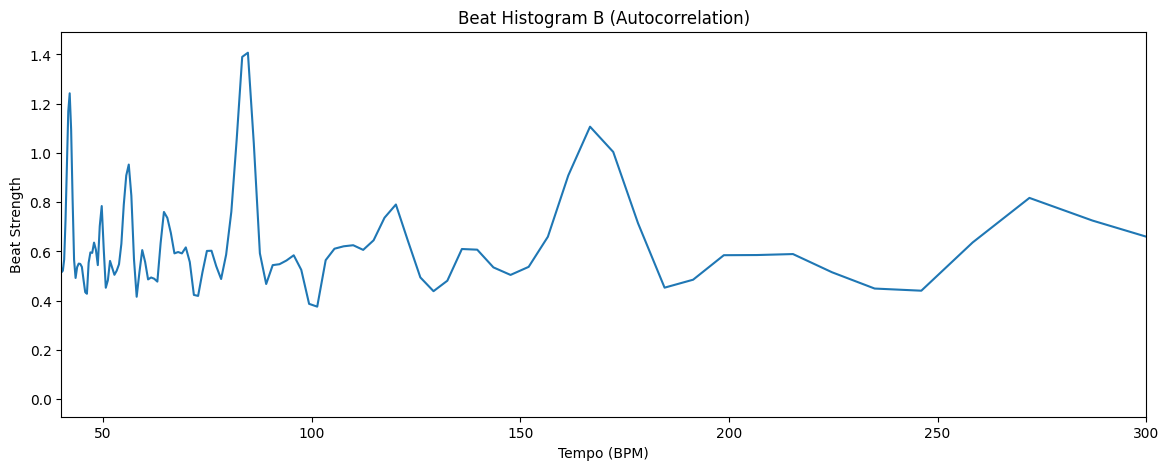

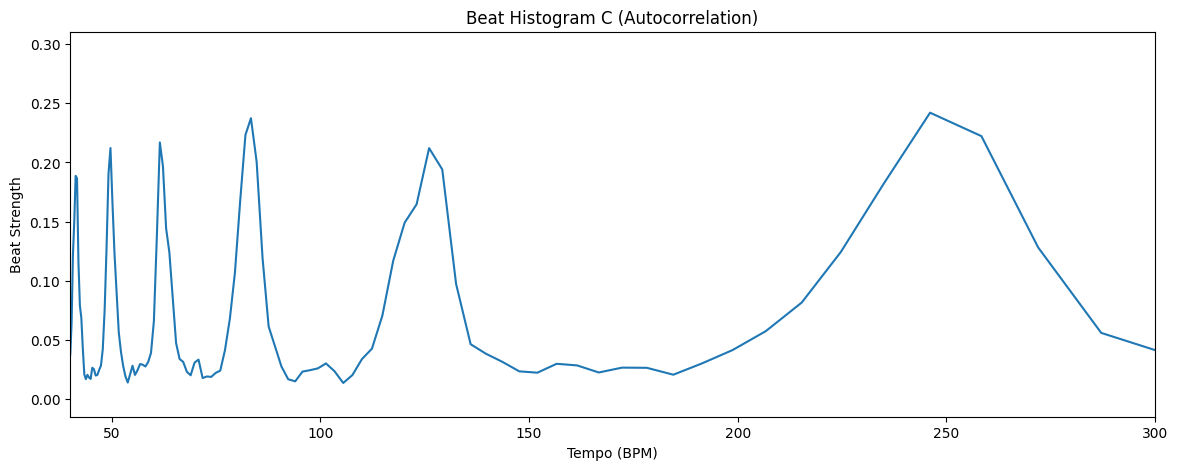

In [ ]:

# 2)
## 2a)
ac_a = librosa.autocorrelate(novelty_a)
lags_a = np.arange(len(ac_a))
lag_times_a = lags_a * hop_length / fs_a
bpms_a = 60 / lag_times_a[1:]   # avoid divide by zero
strength_a = ac_a[1:]
plt.figure()
plt.plot(bpms_a, strength_a)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram A (Autocorrelation)")

## 2b)
ac_b = librosa.autocorrelate(novelty_b)
lags_b = np.arange(len(ac_b))
lag_times_b = lags_b * hop_length / fs_b
bpms_b = 60 / lag_times_b[1:]   # avoid divide by zero
strength_b = ac_b[1:]
plt.figure()
plt.plot(bpms_b, strength_b)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram B (Autocorrelation)")

## 2c)
ac_c = librosa.autocorrelate(novelty_c)
lags_c = np.arange(len(ac_c))
lag_times_c = lags_c * hop_length / fs_c
bpms_c = 60 / lag_times_c[1:]   # avoid divide by zero
strength_c = ac_c[1:]
plt.figure()
plt.plot(bpms_c, strength_c)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram C (Autocorrelation)")



Estimate tempo using librosa.beat.tempo. How do your results compare?

Between autocorrelation and IOIs, which method is most stable? Which is most sensitive to onset errors Do the different files present different behaviors/accuracies?

## Extension

Repeat the activities above but change the frame size and hop length. How does that impact your results?

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content

Tool used: ChatGPT
Input(prompt): how can i convert a stereo wav file into mono in python, simplest way
Output: The simplest way is to just average the two channels.
Stereo audio usually looks like this:
(samples, 2)

Left and right channels.
To convert to mono, take the mean across the channels.

Simple solution
Right after reading the file:
(fs, x) = read('file.wav')

if x.ndim > 1:
    x = x.mean(axis=1)

Description: Instead of using the if statement, I just directly used the 'x = x.mean(axis=1)' in my code because I don't need to check if it's stereo or not. I know the wav file is stereo already, so I just needed to convert it to mono.